# MSE433 Final Project: Rossmann Store Sales
## Sales Prediction & Staffing Decision
### **By:** Yusur Araim



**Dataset:** Rossmann store data (2013–2015)

**Goal:** To predict daily sales and use that to decide how many staff are needed

**Approach:** Use a model to predict sales and also capture uncertainty, then adjust staffing when predictions are less certain

**Models used:** Linear Regression (baseline) vs Quantile Gradient Boosting  

**Key idea:** Add one extra staff member on days where the prediction is more uncertain


# 1. Loading libraries



In [48]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import os

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

PALETTE = {
    "lr": "#4C72B0",
    "qgbr": "#DD8452",
    "actual": "#55A868",
    "buffer": "#C44E52"
}

print("Libraries loaded")

Libraries loaded


# 2. Loading the data files

In [49]:
TRAIN_PATH = "train.csv"
STORE_PATH  = "store.csv"

train = pd.read_csv(TRAIN_PATH, parse_dates=["Date"], dtype={"StateHoliday": str})
store = pd.read_csv(STORE_PATH)

print(f"train shape : {train.shape}")
print(f"store shape : {store.shape}")
train.head()


train shape : (1017209, 9)
store shape : (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


# 3. Cleaning & preparing the data

In [50]:
df = train.merge(store, on="Store", how="left")
df = df[(df["Open"] == 1) & (df["Sales"] > 0)].copy()

# Fill numeric NAs with median
for col in ["CompetitionDistance", "CompetitionOpenSinceMonth",
            "CompetitionOpenSinceYear", "Promo2SinceWeek", "Promo2SinceYear"]:
    df[col] = df[col].fillna(df[col].median())

# Encode categoricals
for col in ["StoreType", "Assortment", "StateHoliday"]:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

print(f"Cleaned shape: {df.shape}")
print(f"Date range  : {df['Date'].min().date()} → {df['Date'].max().date()}")
df.describe()


Cleaned shape: (844338, 18)
Date range  : 2013-01-01 → 2015-07-31


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,844338.000000,844338.000000,844338,844338.000000,844338.000000,844338.0,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000
mean,558.421374,3.520350,2014-04-11 01:08:38.729702912,6955.959134,762.777166,1.0,0.446356,0.001418,0.193578,1.205441,0.936493,5450.031907,7.471434,2009.112023,0.498670,22.625420,2011.877292
min,1.000000,1.000000,2013-01-01 00:00:00,46.000000,8.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,280.000000,2.000000,2013-08-16 00:00:00,4859.000000,519.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,710.000000,6.000000,2008.000000,0.000000,22.000000,2012.000000
50%,558.000000,3.000000,2014-03-31 00:00:00,6369.000000,676.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,2320.000000,8.000000,2010.000000,0.000000,22.000000,2012.000000
75%,837.000000,5.000000,2014-12-11 00:00:00,8360.000000,893.000000,1.0,1.000000,0.000000,0.000000,3.000000,2.000000,6880.000000,9.000000,2011.000000,1.000000,22.000000,2012.000000
max,1115.000000,7.000000,2015-07-31 00:00:00,41551.000000,7388.000000,1.0,1.000000,3.000000,1.000000,3.000000,2.000000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000
std,321.730861,1.723712,NaN,3103.815515,401.194153,0.0,0.497114,0.047578,0.395102,1.363375,0.993099,7801.087197,2.675261,4.973570,0.499999,9.977114,1.179338


# 4. Creating features and splitting the data
Add useful columns like past sales, averages, and date-related info, then split into train and test sets

In [51]:
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

df["Year"]         = df["Date"].dt.year
df["Month"]        = df["Date"].dt.month
df["WeekOfYear"]   = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"]      = df["Date"].dt.quarter
df["IsWeekend"]    = (df["DayOfWeek"] >= 6).astype(int)
df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)
df["IsMonthEnd"]   = df["Date"].dt.is_month_end.astype(int)

df["Lag1"]   = df.groupby("Store")["Sales"].shift(1)
df["Lag7"]   = df.groupby("Store")["Sales"].shift(7)
df["Lag14"]  = df.groupby("Store")["Sales"].shift(14)
df["Roll7"]  = df.groupby("Store")["Sales"].transform(lambda x: x.shift(1).rolling(7).mean())
df["Roll30"] = df.groupby("Store")["Sales"].transform(lambda x: x.shift(1).rolling(30).mean())

df.dropna(inplace=True)
print(f"Shape after lag features: {df.shape}")

FEATURES = [
    "Store", "DayOfWeek", "Month", "Year", "WeekOfYear",
    "Promo", "StateHoliday", "SchoolHoliday",
    "StoreType", "Assortment", "CompetitionDistance",
    "IsWeekend", "IsMonthStart", "IsMonthEnd", "Quarter",
    "Lag1", "Lag7", "Lag14", "Roll7", "Roll30",
]
TARGET = "Sales"

X = df[FEATURES]
y = df[TARGET]

# split data into 80% past (train) and 20% future (test)
split_date = df["Date"].quantile(0.8)
mask = df["Date"] <= split_date
X_train, X_test = X[mask], X[~mask]
y_train, y_test = y[mask], y[~mask]

print(f"Train rows : {len(X_train):,}")
print(f"Test rows  : {len(X_test):,}")
print(f"Split date : {split_date.date()}")


Shape after lag features: (403916, 30)
Train rows : 323,169
Test rows  : 80,747
Split date : 2015-02-10


# 5. Linear Regression Model


In [52]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)
lr_mape = np.mean(np.abs((y_test - lr_pred) / y_test)) * 100

print("Linear Regression Results")
print(f"  MAE  : €{lr_mae:,.0f}")
print(f"  RMSE : €{lr_rmse:,.0f}")
print(f"  R²   : {lr_r2:.4f}")
print(f"  MAPE : {lr_mape:.2f}%")


Linear Regression Results
  MAE  : €957
  RMSE : €1,341
  R²   : 0.7497
  MAPE : 15.01%


# 6. Quantile Gradient Boosting Model

In [53]:
print("Training 10th percentile model...")
gbr_low = GradientBoostingRegressor(
    loss="quantile",
    alpha=0.10,
    n_estimators=50,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
gbr_low.fit(X_train, y_train)

print("Training 50th percentile model...")
gbr_med = GradientBoostingRegressor(
    loss="quantile",
    alpha=0.50,
    n_estimators=50,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
gbr_med.fit(X_train, y_train)

print("Training 90th percentile model...")
gbr_high = GradientBoostingRegressor(
    loss="quantile",
    alpha=0.90,
    n_estimators=50,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
gbr_high.fit(X_train, y_train)

qgbr_pred = gbr_med.predict(X_test)
qgbr_low = gbr_low.predict(X_test)
qgbr_high = gbr_high.predict(X_test)

qgbr_mae = mean_absolute_error(y_test, qgbr_pred)
qgbr_rmse = np.sqrt(mean_squared_error(y_test, qgbr_pred))
qgbr_r2 = r2_score(y_test, qgbr_pred)
qgbr_mape = np.mean(np.abs((y_test - qgbr_pred) / y_test)) * 100

print("Quantile models finished")
print("Quantile GBR Results")
print("MAE:", qgbr_mae)
print("RMSE:", qgbr_rmse)
print("R²:", qgbr_r2)
print("MAPE:", qgbr_mape)

Training 10th percentile model...
Training 50th percentile model...
Training 90th percentile model...
Quantile models finished
Quantile GBR Results
MAE: 861.1081945047482
RMSE: 1327.8302020426504
R²: 0.7543656119397941
MAPE: 13.730864608079818


# 7. Staffing decisions

Decide how many staff are needed using predicted sales.

- Calculate base staff from predicted sales  
- Add 1 extra staff if the prediction is uncertain  
- Keep staff within a reasonable range (3–12)  
- Suggest inventory action based on demand


In [54]:
SALES_PER_STAFF = 1000
STAFF_COST_PER_DAY = 120
MIN_STAFF = 3
MAX_STAFF = 12

def staffing_decision(pred, low, high):
    interval_width = high - low
    relative_uncertainty = interval_width / max(pred, 1)

    base_staff = int(np.clip(round(pred / SALES_PER_STAFF), MIN_STAFF, MAX_STAFF))
    needs_buffer = relative_uncertainty > 0.6

    staff = min(base_staff + 1, MAX_STAFF) if needs_buffer else base_staff

    if pred > 8000:
        inventory = "Restock tonight"
    elif pred > 5000:
        inventory = "Monitor stock"
    else:
        inventory = "Standard levels"

    return staff, needs_buffer, inventory

results = pd.DataFrame({
    "Actual": y_test.values,
    "LR_Pred": lr_pred,
    "QGBR_Pred": qgbr_pred,
    "QGBR_Low": qgbr_low,
    "QGBR_High": qgbr_high,
})

decisions = results.apply(
    lambda r: staffing_decision(r["QGBR_Pred"], r["QGBR_Low"], r["QGBR_High"]),
    axis=1
)

results["Staff_Rec"] = [d[0] for d in decisions]
results["Buffer_Added"] = [d[1] for d in decisions]
results["Inventory_Act"] = [d[2] for d in decisions]

results["Optimal_Staff"] = results["Actual"].apply(
    lambda s: int(np.clip(round(s / SALES_PER_STAFF), MIN_STAFF, MAX_STAFF))
)

results["Fixed_Staff"] = 7

print("Sample output:")
sample_out = results[[
    "Actual","QGBR_Pred","QGBR_Low","QGBR_High",
    "Staff_Rec","Buffer_Added","Inventory_Act"
]].head(10)

print(sample_out.to_string(index=False))

print(f"\nExtra staff added on {results['Buffer_Added'].sum()} days "
      f"({results['Buffer_Added'].mean()*100:.1f}% of test days)")

Sample output:
 Actual   QGBR_Pred    QGBR_Low   QGBR_High  Staff_Rec  Buffer_Added   Inventory_Act
   4773 4352.735927 3627.483809 5733.482459          4         False Standard levels
   3765 4480.294207 3664.671307 5813.240665          4         False Standard levels
   3647 4178.973142 3606.711002 5693.010489          4         False Standard levels
   2809 4138.262230 2632.603649 5693.010489          5          True Standard levels
   7478 6847.161019 5430.327119 8678.222543          7         False   Monitor stock
   6113 6196.931879 5014.700123 7276.500136          6         False   Monitor stock
   6178 5633.795303 4780.189872 6599.647247          6         False   Monitor stock
   5842 5733.184655 4801.472072 6637.733928          6         False   Monitor stock
   4727 5486.820474 4790.438027 6567.896597          5         False   Monitor stock
   3005 4413.913924 2501.541312 5699.452462          5          True Standard levels

Extra staff added on 19159 days (23.7% of test da

# 8. Cost Analysis
Compare model schedule vs always scheduling 7 staff (fixed baseline).

In [55]:
# Compare model-based staffing vs fixed staffing (7 staff every day)

def labour_cost(scheduled, optimal):
    over = np.maximum(scheduled - optimal, 0) * STAFF_COST_PER_DAY
    under = np.maximum(optimal - scheduled, 0) * SALES_PER_STAFF * 0.25
    return over + under

results["Cost_Model"] = labour_cost(results["Staff_Rec"].values, results["Optimal_Staff"].values)
results["Cost_Fixed"] = labour_cost(results["Fixed_Staff"].values, results["Optimal_Staff"].values)

total_model = results["Cost_Model"].sum()
total_fixed = results["Cost_Fixed"].sum()

total_savings = total_fixed - total_model
pct_savings = total_savings / total_fixed * 100
daily_saving = total_savings / len(results)

print("\nCost comparison results:")

print("Days evaluated:", len(results))
print("Fixed staffing cost:", total_fixed)
print("Model staffing cost:", total_model)

print("Total savings:", total_savings)
print("Percent savings:", pct_savings)

print("Avg daily saving:", daily_saving)


Cost comparison results:
Days evaluated: 80747
Fixed staffing cost: 27405280.0
Model staffing cost: 11712570.0
Total savings: 15692710.0
Percent savings: 57.26162987570278
Avg daily saving: 194.344186161715


# 9. Charts
### Chart 1: Model Accuracy Comparison
This compares how well Linear Regression and the Quantile model perform using error metrics and predicted vs actual values.

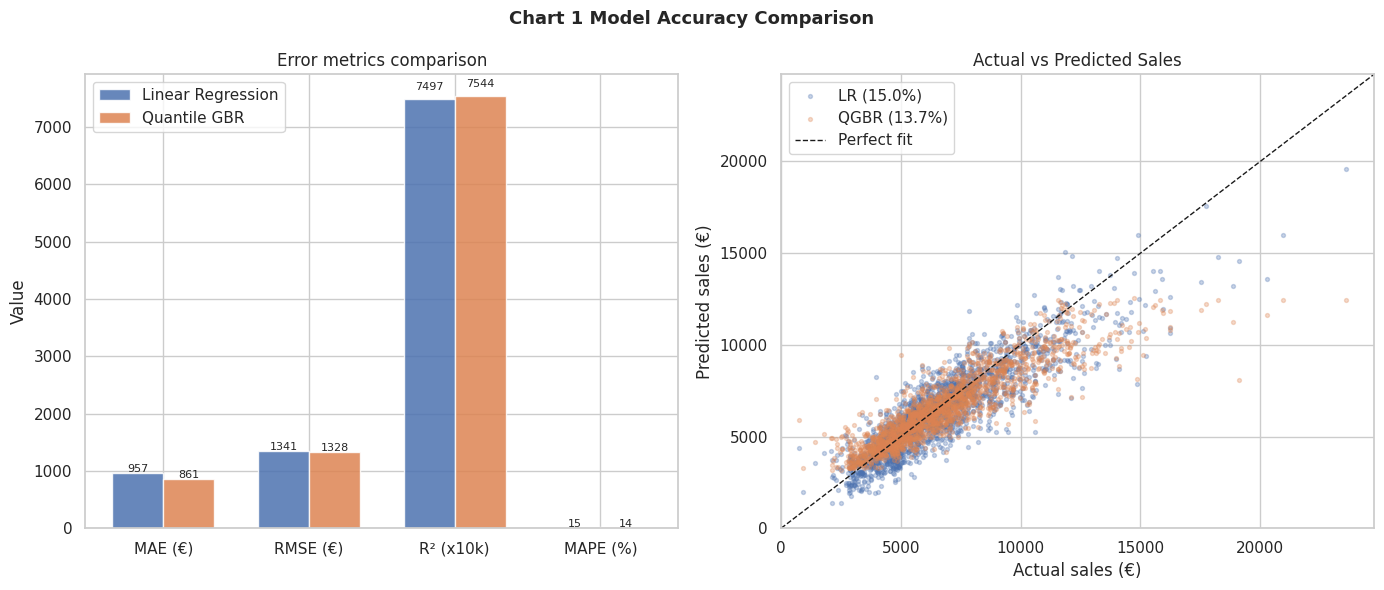

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Chart 1 Model Accuracy Comparison", fontsize=13, fontweight="bold")

# compare error metrics
metrics = ["MAE (€)", "RMSE (€)", "R² (x10k)", "MAPE (%)"]
lr_vals   = [lr_mae, lr_rmse, lr_r2 * 10000, lr_mape]
qgbr_vals = [qgbr_mae, qgbr_rmse, qgbr_r2 * 10000, qgbr_mape]

x = np.arange(len(metrics))
w = 0.35

ax = axes[0]
ax.bar(x - w/2, lr_vals, w, label="Linear Regression", color=PALETTE["lr"], alpha=0.85)
ax.bar(x + w/2, qgbr_vals, w, label="Quantile GBR", color=PALETTE["qgbr"], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Value")
ax.set_title("Error metrics comparison")
ax.legend()

for i, (lv, qv) in enumerate(zip(lr_vals, qgbr_vals)):
    ax.text(i - w/2, lv * 1.02, f"{lv:.0f}", ha="center", fontsize=8)
    ax.text(i + w/2, qv * 1.02, f"{qv:.0f}", ha="center", fontsize=8)

# actual vs predicted
sample = results.sample(min(2000, len(results)), random_state=1)

ax2 = axes[1]
ax2.scatter(sample["Actual"], sample["LR_Pred"],
            alpha=0.3, s=8, color=PALETTE["lr"],
            label=f"LR ({lr_mape:.1f}%)")

ax2.scatter(sample["Actual"], sample["QGBR_Pred"],
            alpha=0.3, s=8, color=PALETTE["qgbr"],
            label=f"QGBR ({qgbr_mape:.1f}%)")

lims = [0, sample["Actual"].max() * 1.05]
ax2.plot(lims, lims, "k--", lw=1, label="Perfect fit")

ax2.set_xlim(lims)
ax2.set_ylim(lims)
ax2.set_xlabel("Actual sales (€)")
ax2.set_ylabel("Predicted sales (€)")
ax2.set_title("Actual vs Predicted Sales")
ax2.legend()

plt.tight_layout()
plt.show()

### Chart 2: Predictions & Uncertainty Over time
This shows predicted sales with confidence intervals & highlights when extra staff is added due to uncertainty


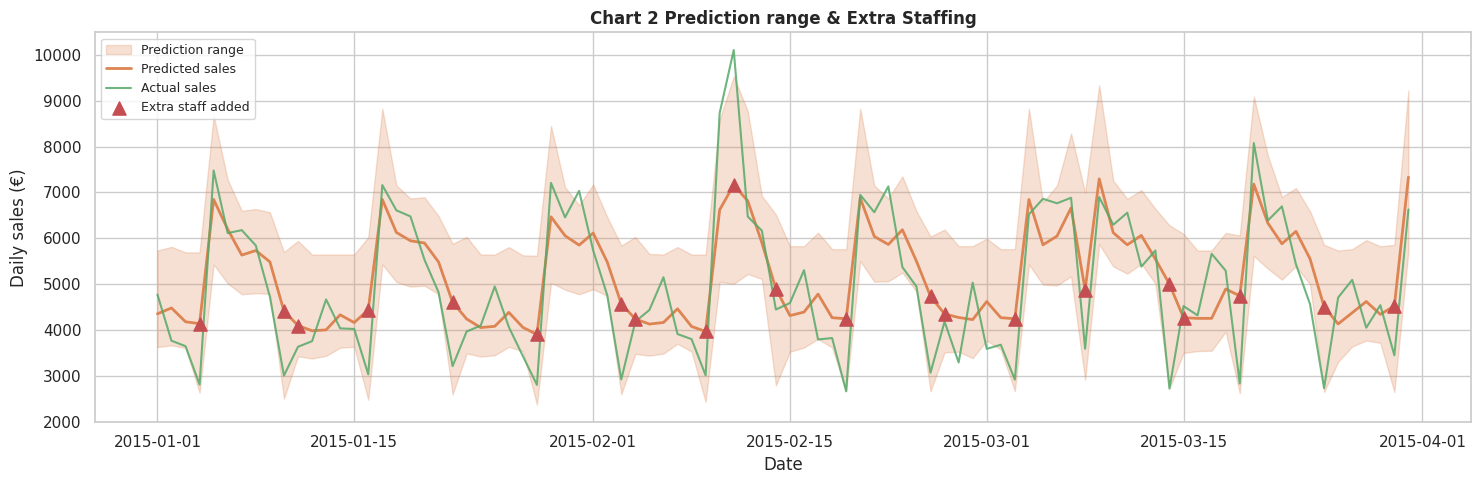

In [57]:
# Chart 2 - prediction range and extra staffing

r = results.iloc[:90].reset_index(drop=True)
dates = pd.date_range("2015-01-01", periods=len(r), freq="D")

fig, ax = plt.subplots(figsize=(15, 5))

# prediction range
ax.fill_between(
    dates,
    r["QGBR_Low"],
    r["QGBR_High"],
    alpha=0.25,
    color=PALETTE["qgbr"],
    label="Prediction range"
)

# predicted and actual sales
ax.plot(
    dates,
    r["QGBR_Pred"],
    color=PALETTE["qgbr"],
    lw=2,
    label="Predicted sales"
)

ax.plot(
    dates,
    r["Actual"],
    color=PALETTE["actual"],
    lw=1.5,
    alpha=0.85,
    label="Actual sales"
)

# mark days with extra staff
buf = r[r["Buffer_Added"]]
ax.scatter(
    dates[buf.index],
    buf["QGBR_Pred"],
    color=PALETTE["buffer"],
    zorder=5,
    s=90,
    marker="^",
    label="Extra staff added"
)

ax.set_title(
    "Chart 2 Prediction range & Extra Staffing",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Daily sales (€)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Chart 3: Staffing Decision Distribution
This shows how many staff the model recommends and compares it to fixed staffing and optimal staffing.

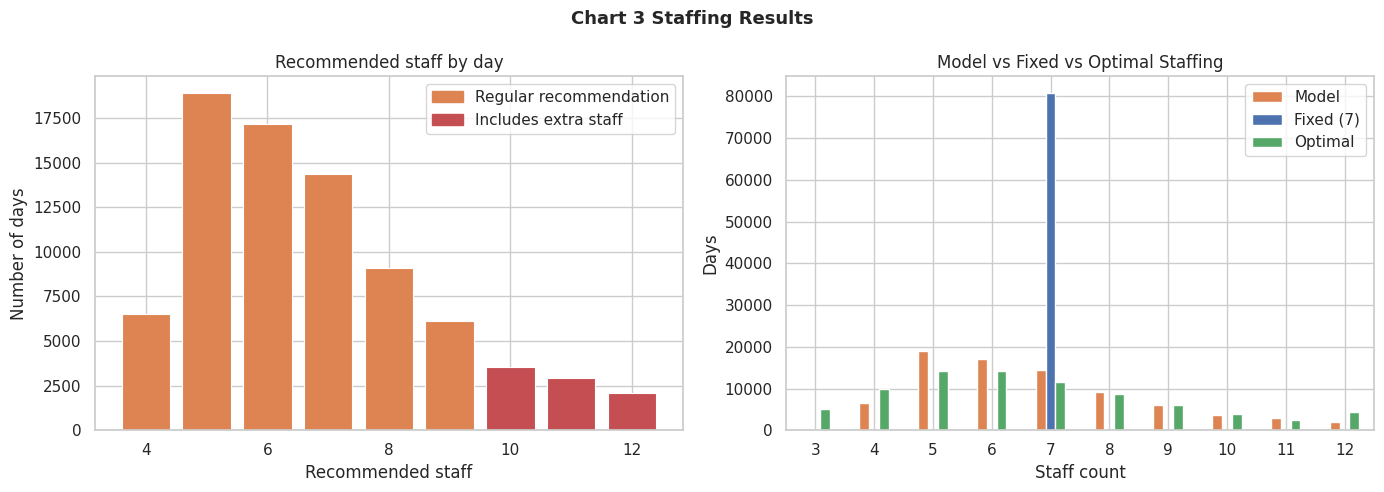

In [58]:
# Chart 3 - staffing results

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chart 3 Staffing Results", fontsize=13, fontweight="bold")

# left chart: recommended staff counts
ax = axes[0]
counts = results["Staff_Rec"].value_counts().sort_index()

colors = [
    PALETTE["buffer"] if results[results["Staff_Rec"] == v]["Buffer_Added"].mean() > 0.3
    else PALETTE["qgbr"]
    for v in counts.index
]

ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.8)
ax.set_xlabel("Recommended staff")
ax.set_ylabel("Number of days")
ax.set_title("Recommended staff by day")

p1 = mpatches.Patch(color=PALETTE["qgbr"], label="Regular recommendation")
p2 = mpatches.Patch(color=PALETTE["buffer"], label="Includes extra staff")
ax.legend(handles=[p1, p2])

# right chart: compare model vs fixed vs optimal
ax2 = axes[1]
compare = pd.DataFrame({
    "Model": results["Staff_Rec"].value_counts().sort_index(),
    "Fixed (7)": results["Fixed_Staff"].value_counts().sort_index(),
    "Optimal": results["Optimal_Staff"].value_counts().sort_index(),
}).fillna(0)

compare.plot(
    kind="bar",
    ax=ax2,
    color=[PALETTE["qgbr"], PALETTE["lr"], PALETTE["actual"]],
    edgecolor="white"
)

ax2.set_xlabel("Staff count")
ax2.set_ylabel("Days")
ax2.set_title("Model vs Fixed vs Optimal Staffing")
ax2.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Chart 4: Cost Savings Analysis

This compares total costs and shows how much money is saved using the model instead of a fixed staffing approach.

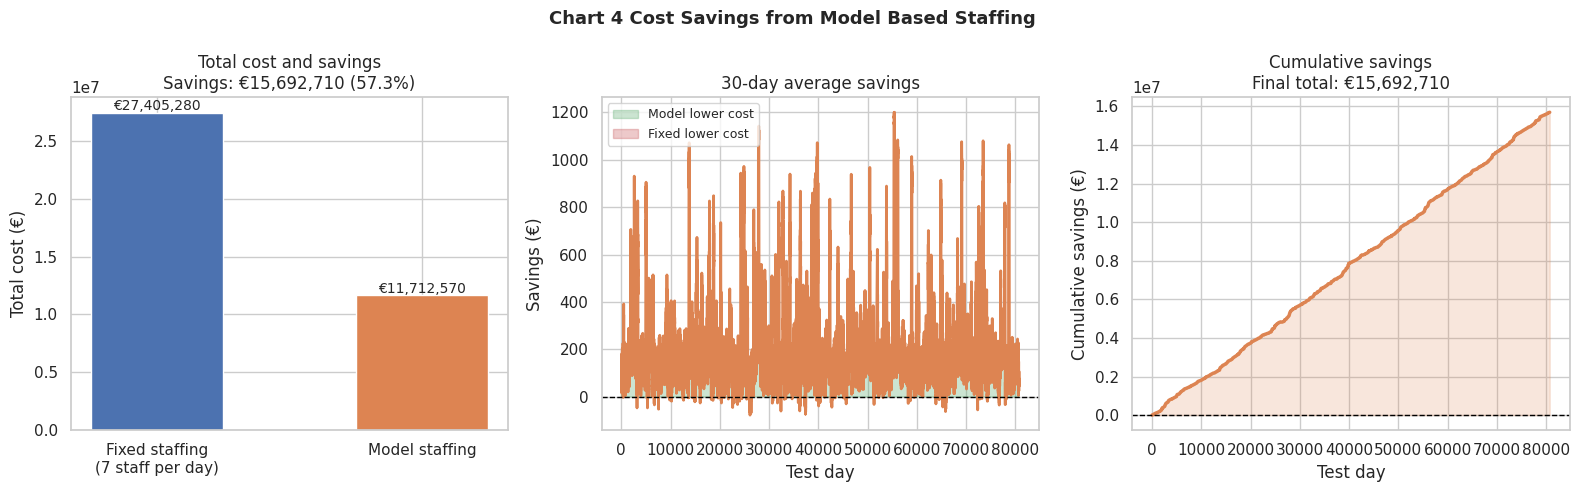

In [59]:
# Chart 4 - cost comparison

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Chart 4 Cost Savings from Model Based Staffing", fontsize=13, fontweight="bold")

# total cost
ax = axes[0]
bars = ax.bar(
    ["Fixed staffing\n(7 staff per day)", "Model staffing"],
    [total_fixed, total_model],
    color=[PALETTE["lr"], PALETTE["qgbr"]],
    width=0.5,
    edgecolor="white"
)

ax.set_ylabel("Total cost (€)")
ax.set_title(f"Total cost and savings\nSavings: €{total_savings:,.0f} ({pct_savings:.1f}%)")

for bar, val in zip(bars, [total_fixed, total_model]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"€{val:,.0f}",
        ha="center",
        fontsize=10
    )

# rolling savings
ax2 = axes[1]
daily_diff = results["Cost_Fixed"] - results["Cost_Model"]
rolling = daily_diff.rolling(30).mean()

ax2.plot(rolling.values, color=PALETTE["qgbr"], lw=2)
ax2.axhline(0, color="black", lw=1, ls="--")

ax2.fill_between(
    range(len(rolling)),
    rolling.values,
    0,
    where=rolling.values > 0,
    alpha=0.3,
    color=PALETTE["actual"],
    label="Model lower cost"
)

ax2.fill_between(
    range(len(rolling)),
    rolling.values,
    0,
    where=rolling.values < 0,
    alpha=0.3,
    color=PALETTE["buffer"],
    label="Fixed lower cost"
)

ax2.set_title("30-day average savings")
ax2.set_xlabel("Test day")
ax2.set_ylabel("Savings (€)")
ax2.legend(fontsize=9)

# cumulative savings
ax3 = axes[2]
cumulative = daily_diff.cumsum().values

ax3.plot(cumulative, color=PALETTE["qgbr"], lw=2.5)
ax3.fill_between(range(len(cumulative)), cumulative, alpha=0.2, color=PALETTE["qgbr"])
ax3.axhline(0, color="black", lw=1, ls="--")

ax3.set_title(f"Cumulative savings\nFinal total: €{cumulative[-1]:,.0f}")
ax3.set_xlabel("Test day")
ax3.set_ylabel("Cumulative savings (€)")

plt.tight_layout()
plt.show()

## 10. Final Summary

In [60]:
print("=" * 55)
print("Final results summary")
print("=" * 55)

print("\nAccuracy")
print(f"{'Metric':<10} {'Linear Regression':>20} {'Quantile GBR':>18}")
print("-" * 50)

print(f"{'MAE':<10} {lr_mae:>20,.0f} {qgbr_mae:>18,.0f}")
print(f"{'RMSE':<10} {lr_rmse:>20,.0f} {qgbr_rmse:>18,.0f}")
print(f"{'R²':<10} {lr_r2:>20.4f} {qgbr_r2:>18.4f}")
print(f"{'MAPE (%)':<10} {lr_mape:>20.2f} {qgbr_mape:>18.2f}")

print("\nCost savings")
print(f"Fixed schedule cost : €{total_fixed:,.0f}")
print(f"Model schedule cost : €{total_model:,.0f}")
print(f"Total savings       : €{total_savings:,.0f}")
print(f"Savings (%)         : {pct_savings:.1f}%")
print(f"Avg daily saving    : €{daily_saving:.2f}")
print(f"Extra staff days    : {results['Buffer_Added'].sum():,}")
print(f"Buffer rate         : {results['Buffer_Added'].mean()*100:.1f}%")

print("=" * 55)

Final results summary

Accuracy
Metric        Linear Regression       Quantile GBR
--------------------------------------------------
MAE                         957                861
RMSE                      1,341              1,328
R²                       0.7497             0.7544
MAPE (%)                  15.01              13.73

Cost savings
Fixed schedule cost : €27,405,280
Model schedule cost : €11,712,570
Total savings       : €15,692,710
Savings (%)         : 57.3%
Avg daily saving    : €194.34
Extra staff days    : 19,159
Buffer rate         : 23.7%
